# <b>Programming for Data Science Project

meter numero do henrique
fazer boxplot com todas as colunas qu têm missing values instead uma por uma\
meter titulos como ta nas guidelines(carlota sabe)\
fazer um indice\
fazer boxplots para todos os missing values\
verfiicar o datatype de cada coluna e mudar oq tem a ser udado ANTES DO MULTIINDEX mas dps dos missing values

dúvidas: \
não deviamos tratar dos missing values só depois de tirar os duplicates ? assim quando usamos a mean ou a median esse valor está a ser influenciado por isso \
por ex na working age population tamos a basear nos nas outras cidades alemãs mas tipo será esse o melhor fator para nos basearmos? não nos deviamos basear por exemplo nas cidades que tenham uma população semelhante?\



## <b>1. Introduction and Project Setup

### <b> 1.1. Our Group

**Group 19** 
- Carlota Marto 20241729 
- Henrique Santos 2024
- Laura Lisboa 20241783
- Tiago Carvalho 20241728

 ### <b> 1.2. Project Goal

&nbsp;&nbsp;&nbsp;&nbsp;The primary goal of this Notebook series is to perform a comprehensive, data-driven analysis to **empower users in making informed living decisions across European countries.** \
&nbsp;&nbsp;&nbsp;&nbsp;This project aims to simplify the complex choice of where to live by analyzing key national characteristics, such as **Cost of Living**, **Population Density** and **Employment**, and translating raw data into an **interpretable framework.** \
&nbsp;&nbsp;&nbsp;&nbsp;Ultimately, this project seeks to answer the central question: \
&nbsp;&nbsp;&nbsp;&nbsp;***Which European countries offer the optimal alignment with a user's personal values and life goals, based on quantitative metrics?***


 ### <b> 1.3. Import All the Necessary Libraries, the Dataset and Adjust the Name of Some Columns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
dataset = pd.read_csv(r'C:\Users\laura\Desktop\Prog 4 DS\PROJECT\city_data.csv', sep = '|', header = 1, index_col = 0)
dataset.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


**Add Information to the Name of the Columns and Correct Mistakes**

In [13]:
dataset.columns
#This line allows us to see the name of all the columns of the dataset

Index(['Population Density', 'Population', 'Working Age Population ',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Avgerage Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

&nbsp;&nbsp;&nbsp;&nbsp;We can observe that the column 'Working Age Population ' has a space in front, which can make it confusing to code with. Also, the column 'Avgerage Rent Price' has a spelling mistake which we are going to correct.\
&nbsp;&nbsp;&nbsp;&nbsp;We also decided that the dataset would become more clear if we added more information to some columns, for instance, the units in which the variable is measured or other informations we found useful.

In [15]:
dataset = dataset.rename(columns={'Population Density': 'Population Density (per km2)', 
                                  'Working Age Population ': 'Working Age Population (15-64 years)',
                                  'GDP per Capita': 'GDP per Capita ($)',
                                  'Days of very strong heat stress' : 'Days of very strong heat stress (>38ºC)',
                                  'Average Monthly Salary': 'Average Monthly Salary (€)', 
                                  'Avgerage Rent Price' : 'Average Rent Price (€)',
                                 })

In [16]:
dataset.head(1)

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita ($),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;The variable 'GDP per Capita' is measured in $ and, as there are other two columns where the values are measured in €, we are going to do the conversion of all the values in that column. We are sure that, that way, it is less confusing for someone trying to find the best place to live.\
&nbsp;&nbsp;&nbsp;&nbsp;In the third of November of 2025, the cost of 1 dolar was equal to 0.87 euros. 

In [18]:
dataset['GDP per Capita ($)'] = dataset['GDP per Capita ($)'] * 0.87  

In [19]:
dataset = dataset.rename(columns={'GDP per Capita ($)' : 'GDP per Capita (€)'})
dataset.head(1)

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


### **Adjust Some Data Types**

In [21]:
dataset.info()
#this line allows us to see the datatype of each column

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, Vienna, Austria to Adana, Turkiye
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Population Density (per km2)             85 non-null     float64
 1   Population                               86 non-null     int64  
 2   Working Age Population (15-64 years)     85 non-null     float64
 3   Youth Dependency Ratio                   86 non-null     float64
 4   Unemployment Rate                        85 non-null     float64
 5   GDP per Capita (€)                       85 non-null     float64
 6   Days of very strong heat stress (>38ºC)  86 non-null     int64  
 7   Main Spoken Languages                    85 non-null     object 
 8   Average Monthly Salary (€)               86 non-null     int64  
 9   Average Rent Price (€)                   86 non-null     int64  
 10  Average Cost of Living         

&nbsp;&nbsp;&nbsp;&nbsp;As we can see, there are some columns classified as 'float64' that do not make sense. For example, the Working Age Population and the GDP per Capita. We decided to change them to integers to make it easier to read. (Average Price Groceries also has that problem but we chose to ignore it for now because it is going to be removed.)

## <b>2. Data Wrangling and Exploratory Analysis 

&nbsp;&nbsp;&nbsp;&nbsp;In this part, we are going to handle the duplicate records and the missing values. We chose to handle the duplicate records firstly so that those records do not interfere with the imputation of the missing values

### **2.1. How to Handle Duplicate Records**

In [26]:
duplicate_records = dataset[dataset.duplicated(keep = False)]
duplicate_records
#these two lines shows us the duplicate records in the dataset

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;In the whole dataset we only have two duplicates: Berlin and Malaga. In the next line of code we are removing them.

In [28]:
dataset.drop_duplicates(inplace = True)

### **2.2. How to Handle Missing Values**

&nbsp;&nbsp;&nbsp;&nbsp;Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [31]:
dataset.isna().sum()

Population Density (per km2)                1
Population                                  0
Working Age Population (15-64 years)        1
Youth Dependency Ratio                      0
Unemployment Rate                           1
GDP per Capita (€)                          1
Days of very strong heat stress (>38ºC)     0
Main Spoken Languages                       1
Average Monthly Salary (€)                  0
Average Rent Price (€)                      0
Average Cost of Living                      0
Average Price Groceries                    78
Last Data Update                            0
dtype: int64


**Column 'Average Price Groceries'**

&nbsp;&nbsp;&nbsp;&nbsp;In the column 'Average Price Groceries' there are 80 missing values out of the 86 rows total. As there are only 6 records of average price groceries, this does not add up any valuable information, therefore, we decided to remove it.

In [44]:
dataset.drop('Average Price Groceries', axis = 1, inplace = True)
dataset.head(1) #this is just to visualise that the columns is not there anymore

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00


### 2.1.1. Missing Values in Categorical Variables

**Missing Value in 'Main Spoken Languages'**

&nbsp;&nbsp;&nbsp;&nbsp;For the missing value in 'Main Spoken Languages', we first need to understand in what row is the missing value located

In [49]:
dataset[dataset['Main Spoken Languages'].isna()]

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,NaN,3200,1100,2050,2024-01-15 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;As it is a **categorical** variable we have to deal with it with the mode. If we did not have the information about the country of the city, we would apply the mode to all the cities in the dataset, but, as we know that "Dusseldorf" is located in Germany we only apply the mode to all the **german cities** for a more accurate result.

In [52]:
dataset.loc[dataset.index.str.contains('Germany'), ['Main Spoken Languages']].mode()

,Main Spoken Languages
0,German


&nbsp;&nbsp;&nbsp;&nbsp;As we can observe, the most common main spoken language in german cities of the dataset is **'German'**. Therefore, we will replace the missing value with 'German'.

In [55]:
dataset.loc['Dusseldorf, Germany', 'Main Spoken Languages'] = 'German'
dataset.loc[['Dusseldorf, Germany']]

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


### 2.1.2. Missing Values in Numerical Variables

&nbsp;&nbsp;&nbsp;&nbsp;We can do many things with missing numerical values. There are cases where we must replace with the **median** and others where we must use the **mean**. This all depends if those columns have outliers or not, therefore, we decided that the best way to verify outliers is by creating a **boxplot for each variable**. As the columns with missing values have very different scales, we cannot put them all in the same graphic

\
**Missing Value in 'Working Age Population'**

&nbsp;&nbsp;&nbsp;&nbsp;For the missing value in the column 'Working Age Population', by the same logic we will replace it based on the other **german cities** as the only missing value is also located in Dusseldorf in Germany. This time, as it is a **numerical** variable instead of categorical we need to verify if there are outliers so, we create a boxplot that shows the distribution of working age population in german cities.

In [61]:
dataset[dataset['Working Age Population (15-64 years)'].isna()]
#Here we can confirm that the only missing value is actually in a german city

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


In [63]:
german_cities = dataset[dataset.index.str.contains('Germany')]
german_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29 00:00:00
"Hamburg, Germany",461.0,3315036,2181857.0,21.5,3.2,53120.46,0,"German, English, Turkish",3500,1100,2100,2024-07-10 00:00:00
"Munich, Germany",529.0,2907752,1955041.0,21.1,2.1,73049.55,1,"German, English",3540,1500,2550,2023-03-16 00:00:00
"Cologne, Germany",1233.0,2002550,1335299.0,20.8,3.9,52469.70,3,"German, English, Turkish",3200,1030,2000,2024-11-23 00:00:00
"Frankfurt am Main, Germany",631.0,2710501,1791435.0,22.0,3.2,60353.64,6,"German, English",3800,1300,2350,2023-02-04 00:00:00


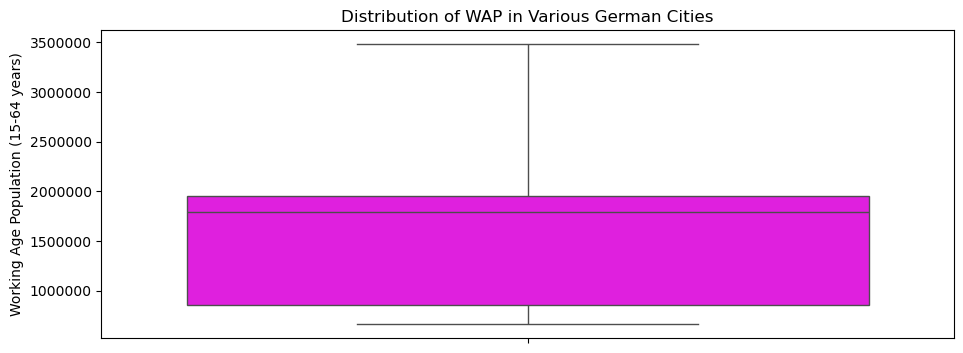

In [65]:
plt.figure(figsize = (11,4))
sns.boxplot(data = german_cities['Working Age Population (15-64 years)'], color = '#FF00FE')
plt.title('Distribution of WAP in Various German Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

&nbsp;&nbsp;&nbsp;&nbsp;As we can see above, there are no outliers in the Working Age Population in german cities. The mean is sensible to outliers, but as we do not have any we should use it to find the missing value.

In [76]:
print(f'The average Working Age Population in german cities is: {german_cities['Working Age Population (15-64 years)'].mean().round()}')

The average Working Age Population in german cities is: 1658169.0


In [100]:
dataset.loc['Dusseldorf, Germany', ['Working Age Population (15-64 years)']] =  german_cities['Working Age Population (15-64 years)'].mean().round()
dataset.loc[['Dusseldorf, Germany']]
#this two lines replace the missing value by the mean that was shown before and display the row with information about Dusseldorf, Germany

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,1658169.0,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


### Missing Value in 'Population Density'

In [80]:
dataset[dataset['Population Density (per km2)'].isna()]	
#this line allows us to see what city has the missing value in Population Density

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


By the same logic as the last one, we're going to compare Valencia to the other spainish cities and then, see the distribution of the Population Density in those cities. If it has outliers, we use the median, if not, we use the mean

In [82]:
spanish_cities = dataset[dataset.index.str.contains('Spain')]
spanish_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Madrid, Spain",873.0,6882461,4617753.0,23.0,10.8,44387.40,18,Spanish,2271,1100,1589,2023-05-14 00:00:00
"Barcelona, Spain",1918.0,5034925,3331345.0,22.6,11.0,39163.92,0,"Spanish, Catalan",2094,1450,1630,2024-10-18 00:00:00
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.90,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00
"Seville, Spain",330.0,1549641,1037225.0,25.0,21.6,26103.48,53,Spanish,2300,650,1150,2024-09-01 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,2023-11-27 00:00:00


Text(0.5, 1.0, 'Distribution of Population Density in Various Spanish Cities')

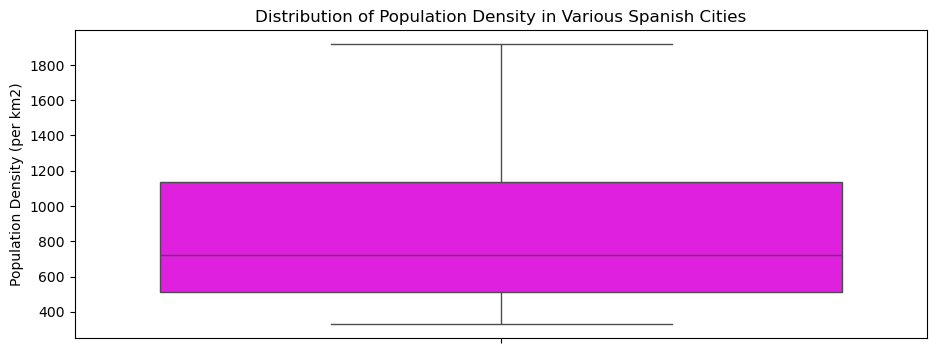

In [132]:
plt.figure(figsize = (11,4))
sns.boxplot(data = spanish_cities['Population Density (per km2)'], color = '#FF00FE')
plt.title('Distribution of Population Density in Various Spanish Cities')

In [134]:
print(f'The average Density Population in spanish cities is: {spanish_cities['Population Density (per km2)'].mean()}')

The average Density Population in spanish cities is: 923.0


In [136]:
dataset.loc['Valencia, Spain', ['Population Density (per km2)']] =  spanish_cities['Population Density (per km2)'].mean()
dataset.loc[['Valencia, Spain']]
#the boxplot does not have outliers, so we replace it by the mean

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
"Valencia, Spain",923.0,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00,923.0,923.0


### Missing Value in 'Unemployment Rate'

We are going to repeat the process for all the left missing values. Firstly, see what city has the missing value in the Unemployment Rate column, then, create a new dataset with all the cities in that country and create a box plot with the distribution of the unemployment rate in those cities to verify the existence of outliers.

In [121]:
dataset[dataset['Unemployment Rate'].isna()]	
#we verify the missing value is in Gent in Belgium

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00,NaN,NaN


In [124]:
belgium_cities = dataset[dataset.index.str.contains('Belgium')]
belgium_cities.head()

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
"Brussels, Belgium",681.0,3284548,2137425.0,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00,NaN,NaN
"Antwerp, Belgium",928.0,1139663,723396.0,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00,NaN,NaN
"Gent, Belgium",552.0,645813,417832.0,24.80,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00,NaN,NaN
"Bruges, Belgium",840.0,119765,74600.0,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25 00:00:00,NaN,NaN


Text(0.5, 1.0, 'Distribution of Unemployment Rate in Various Belgium Cities')

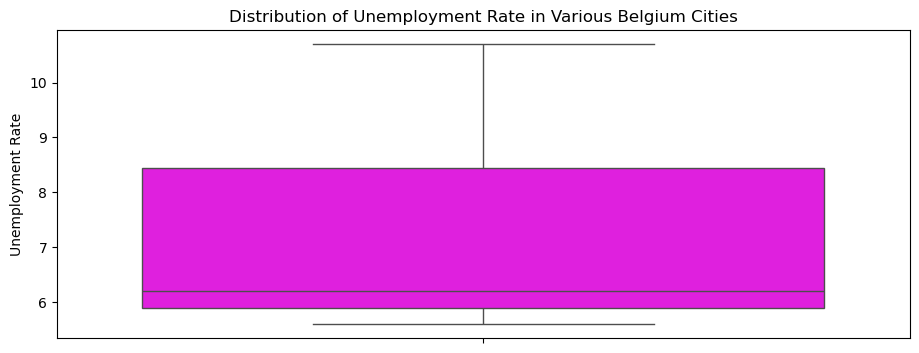

In [130]:
plt.figure(figsize = (11,4))
sns.boxplot(data = belgium_cities['Unemployment Rate'], color = '#FF00FE')
plt.title('Distribution of Unemployment Rate in Various Belgium Cities')

In [128]:
print(f'The average Unemployment Rate in belgium cities is: {belgium_cities['Unemployment Rate'].mean()}')

The average Unemployment Rate in belgium cities is: 7.5


In [139]:
dataset.loc['Gent, Belgium', ['Unemployment Rate']] =  belgium_cities['Unemployment Rate'].mean()
dataset.loc[['Gent, Belgium']]
#the boxplot does not have outliers, so we replace it by the mean

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00,NaN,NaN


### Missing Value in 'GDP per Capita'

In [146]:
dataset[dataset['GDP per Capita (€)'].isna()]	
#we verify the missing value is in Lemesos in Cyprus

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00,NaN,NaN


In [150]:
cyprus_cities = dataset[dataset.index.str.contains('Cyprus')]
cyprus_cities.head()

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Density Population (per km2),Populaton Density (per km2)
City,,,,,,,,,,,,,,
"Lefkosia, Cyprus",130.0,356400,237000.0,23.06,9.6,30369.09,45,"Greek, Turkish, English",1486,700,1350,2024-04-08 00:00:00,NaN,NaN
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00,NaN,NaN


In [ ]:
plt.figure(figsize = (11,4))
sns.boxplot(data = cyprus_cities['GDP per Capita (€)'], color = '#FF00FE')
plt.title('Distribution of GDP per Capita in Various Belgium Cities')